# 3단계 · 전략 구현

이 노트북에서는 실제 매매에서 많이 쓰이는 기술 분석 전략들을 vectorbt로 구현합니다.

## 학습 목표
1. 이동평균 골든크로스 전략 구현
2. RSI(Relative Strength Index) 역추세 전략 구현
3. MACD(Moving Average Convergence Divergence) 전략 구현
4. 전략별 성과 비교

---
## 기술 지표란?

가격 및 거래량 데이터를 수학적으로 가공해서 **매수·매도 시점**을 포착하려는 도구입니다.

| 유형 | 대표 지표 | 특징 |
|-----|---------|------|
| **추세 추종** | 이동평균, MACD | 상승 추세에서 매수, 하락 추세에서 매도 |
| **역추세** | RSI, Stochastic | 과매수·과매도 구간에서 반전 예상 |
| **변동성** | Bollinger Bands | 가격이 밴드 밖으로 나갈 때 신호 |

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 (AAPL 2018~2023)
ticker = 'AAPL'
df = yf.download(ticker, start='2018-01-01', end='2023-12-31',
                 auto_adjust=True, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close = df['Close']
print(f'데이터 기간: {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'총 거래일: {len(close)}일')

데이터 기간: 2018-01-02 ~ 2023-12-29
총 거래일: 1509일


---
## 전략 1 · 이동평균 골든크로스

### 개념
- **골든크로스**: 단기 이동평균(MA)이 장기 MA를 **아래에서 위로** 돌파 → 매수 신호
- **데드크로스**: 단기 MA가 장기 MA를 **위에서 아래로** 돌파 → 매도 신호

```
     단기MA (20일)
     /  골든크로스 ↑ 매수
----/-----------------------------------
   /   장기MA (60일)
      데드크로스 ↓ 매도
```

### 특징
- 추세 추종형 → 큰 추세에서 수익, 횡보장에서 손실
- 파라미터: 단기 창 크기(fast), 장기 창 크기(slow)

In [16]:
# ─── 이동평균 계산 ───────────────────────────────────────────────
fast_window = 20   # 단기: 20일 이동평균
slow_window = 60   # 장기: 60일 이동평균

fast_ma = close.rolling(fast_window).mean()
slow_ma = close.rolling(slow_window).mean()

# ─── 시그널 생성 ─────────────────────────────────────────────────
# 골든크로스: 이전에는 fast < slow, 현재는 fast >= slow
gc_entries = (fast_ma >= slow_ma) & (fast_ma.shift(1) < slow_ma.shift(1))
# 데드크로스: 이전에는 fast >= slow, 현재는 fast < slow
gc_exits   = (fast_ma < slow_ma)  & (fast_ma.shift(1) >= slow_ma.shift(1))

print(f'골든크로스(매수) 발생: {gc_entries.sum()}회')
print(f'데드크로스(매도) 발생: {gc_exits.sum()}회')

골든크로스(매수) 발생: 15회
데드크로스(매도) 발생: 15회


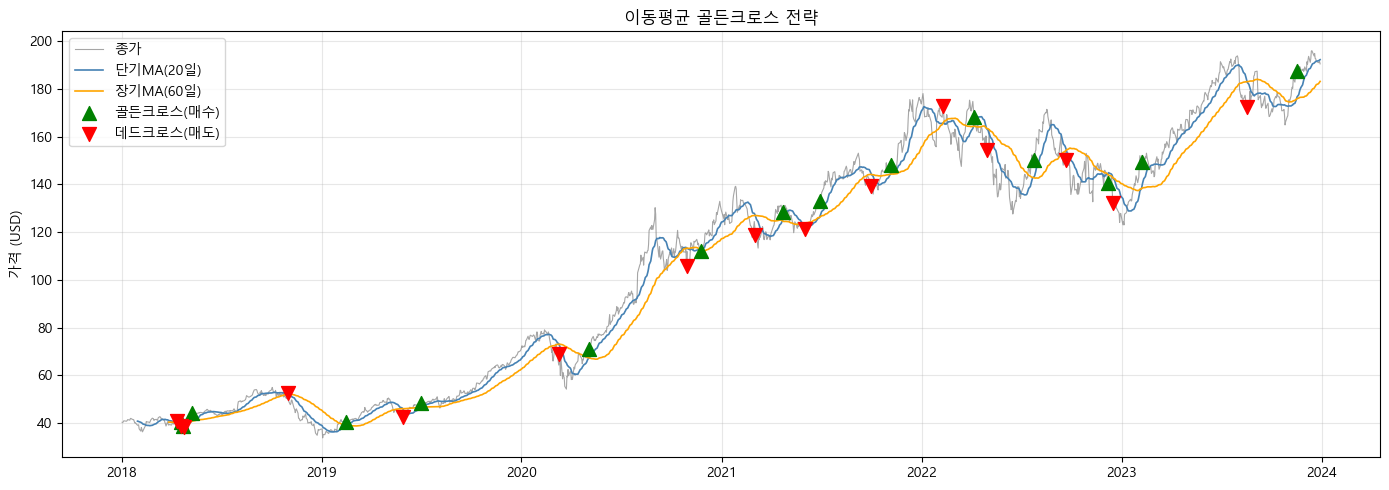

In [17]:
# ─── 시각화: 가격 + 이동평균 + 시그널 ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close.index, close, color='gray', linewidth=0.8, label='종가', alpha=0.7)
ax.plot(fast_ma.index, fast_ma, color='steelblue', linewidth=1.2, label=f'단기MA({fast_window}일)')
ax.plot(slow_ma.index, slow_ma, color='orange', linewidth=1.2, label=f'장기MA({slow_window}일)')

# 골든크로스 시점 표시
ax.scatter(close.index[gc_entries], close[gc_entries],
           marker='^', color='green', s=100, zorder=5, label='골든크로스(매수)')
ax.scatter(close.index[gc_exits], close[gc_exits],
           marker='v', color='red',   s=100, zorder=5, label='데드크로스(매도)')

ax.set_title('이동평균 골든크로스 전략')
ax.set_ylabel('가격 (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# ─── 백테스트 실행 ───────────────────────────────────────────────
pf_gc = vbt.Portfolio.from_signals(
    close, gc_entries, gc_exits,
    fees=0.001, slippage=0.001, freq='D'
)

print('=== 골든크로스 전략 성과 ===')
print(f'총 수익률  : {pf_gc.total_return():.2%}')
print(f'연평균수익률: {pf_gc.annualized_return():.2%}')
print(f'샤프 비율  : {pf_gc.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_gc.max_drawdown():.2%}')
print(f'총 거래수  : {pf_gc.trades.count()}회')

=== 골든크로스 전략 성과 ===
총 수익률  : 194.14%
연평균수익률: 29.82%
샤프 비율  : 1.10
최대 낙폭  : -21.63%
총 거래수  : 15회


---
## 전략 2 · RSI 역추세 전략

### RSI 계산 원리

$$RSI = 100 - \frac{100}{1 + RS} \quad\text{, where }RS = \frac{\text{평균 상승폭}}{\text{평균 하락폭}}$$

### 해석
| RSI 값 | 의미 | 전략 신호 |
|--------|------|----------|
| > 70   | 과매수 (너무 많이 올라감) | 매도 |
| < 30   | 과매도 (너무 많이 내려감) | 매수 |
| 30~70  | 중립 | 관망 |

### 특징
- 역추세형 → 큰 추세가 없는 **횡보장에서 효과적**
- 강한 추세장에서는 과매수/과매도 상태가 오래 지속될 수 있음

In [19]:
# ─── RSI 계산 ────────────────────────────────────────────────────
def calc_rsi(close: pd.Series, window: int = 14) -> pd.Series:
    """RSI 계산"""
    delta = close.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    # EWM 방식 (Wilder's smoothing)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi.rename('RSI')

rsi_window  = 14
rsi_oversold  = 30   # 과매도 기준
rsi_overbought = 70  # 과매수 기준

rsi = calc_rsi(close, rsi_window)

print(f'RSI 통계:')
print(f'  평균: {rsi.mean():.1f}')
print(f'  최솟값: {rsi.min():.1f}')
print(f'  최댓값: {rsi.max():.1f}')
print(f'  RSI < 30 (과매도): {(rsi < 30).sum()}일')
print(f'  RSI > 70 (과매수): {(rsi > 70).sum()}일')

RSI 통계:
  평균: 55.6
  최솟값: 16.1
  최댓값: 85.7
  RSI < 30 (과매도): 27일
  RSI > 70 (과매수): 207일


In [20]:
# ─── RSI 시그널 생성 ──────────────────────────────────────────────
# RSI가 30 아래에서 위로 올라올 때 매수
rsi_entries = (rsi > rsi_oversold)   & (rsi.shift(1) <= rsi_oversold)
# RSI가 70 위에서 아래로 내려올 때 매도
rsi_exits   = (rsi < rsi_overbought) & (rsi.shift(1) >= rsi_overbought)

print(f'RSI 매수 시그널: {rsi_entries.sum()}회')
print(f'RSI 매도 시그널: {rsi_exits.sum()}회')

RSI 매수 시그널: 14회
RSI 매도 시그널: 41회


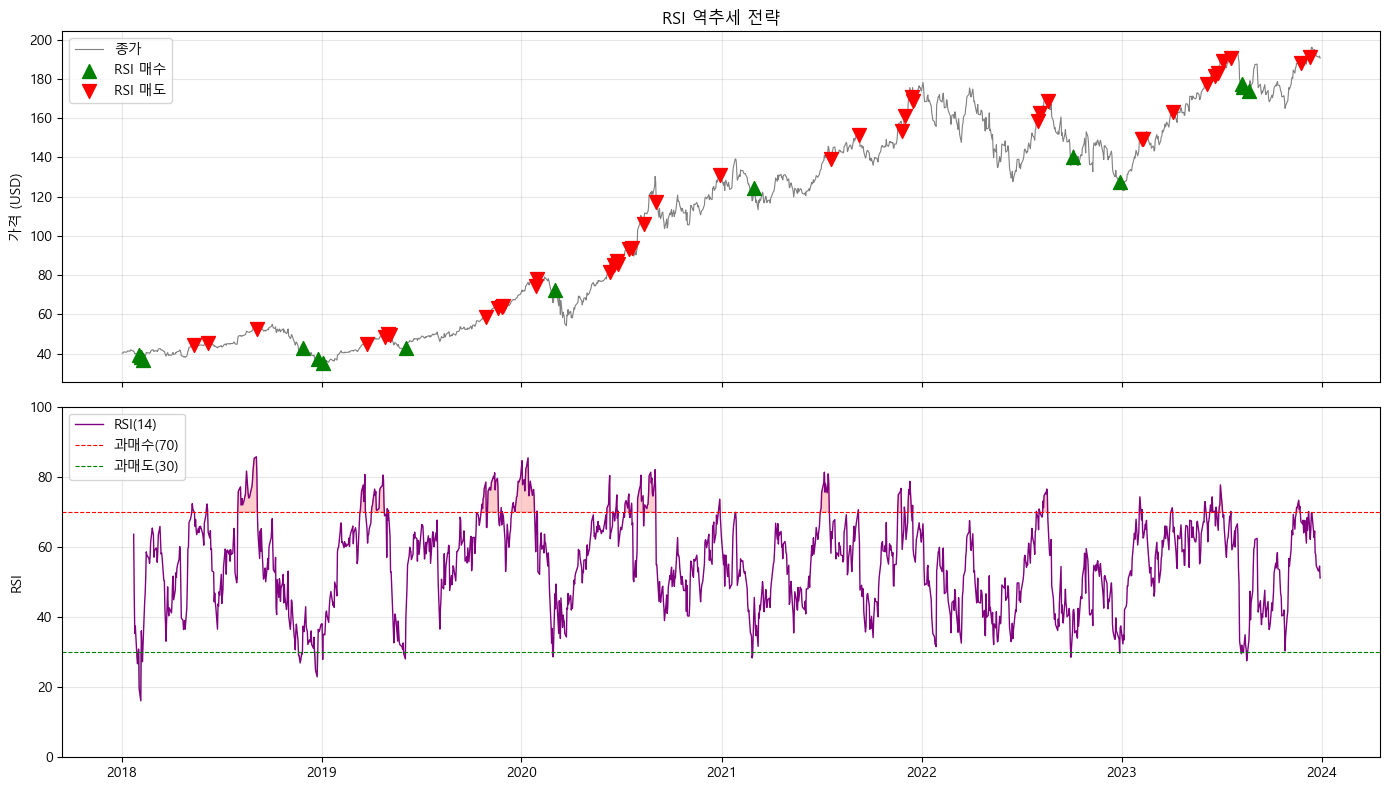

In [21]:
# ─── 시각화: 가격 + RSI ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 상단: 가격 차트
ax1.plot(close, color='gray', linewidth=0.8, label='종가')
ax1.scatter(close.index[rsi_entries], close[rsi_entries],
            marker='^', color='green', s=100, zorder=5, label='RSI 매수')
ax1.scatter(close.index[rsi_exits], close[rsi_exits],
            marker='v', color='red', s=100, zorder=5, label='RSI 매도')
ax1.set_title('RSI 역추세 전략')
ax1.set_ylabel('가격 (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 하단: RSI 차트
ax2.plot(rsi, color='purple', linewidth=1, label='RSI(14)')
ax2.axhline(rsi_overbought, color='red',   linestyle='--', linewidth=0.8, label=f'과매수({rsi_overbought})')
ax2.axhline(rsi_oversold,   color='green', linestyle='--', linewidth=0.8, label=f'과매도({rsi_oversold})')
ax2.fill_between(rsi.index, rsi_oversold, rsi,
                 where=(rsi < rsi_oversold), alpha=0.2, color='green')
ax2.fill_between(rsi.index, rsi_overbought, rsi,
                 where=(rsi > rsi_overbought), alpha=0.2, color='red')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# ─── RSI 전략 백테스트 ────────────────────────────────────────────
pf_rsi = vbt.Portfolio.from_signals(
    close, rsi_entries, rsi_exits,
    fees=0.001, slippage=0.001, freq='D'
)

print('=== RSI 전략 성과 ===')
print(f'총 수익률  : {pf_rsi.total_return():.2%}')
print(f'연평균수익률: {pf_rsi.annualized_return():.2%}')
print(f'샤프 비율  : {pf_rsi.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_rsi.max_drawdown():.2%}')
print(f'총 거래수  : {pf_rsi.trades.count()}회')

=== RSI 전략 성과 ===
총 수익률  : 122.68%
연평균수익률: 21.37%
샤프 비율  : 0.87
최대 낙폭  : -26.94%
총 거래수  : 7회


---
## 전략 3 · MACD 전략

### MACD 계산 원리

```
MACD선   = 단기 EMA(12) - 장기 EMA(26)
Signal선  = MACD선의 EMA(9)
Histogram = MACD선 - Signal선
```

### 매매 신호
- **MACD선이 Signal선을 상향 돌파** → 매수 신호
- **MACD선이 Signal선을 하향 돌파** → 매도 신호

### 특징
- EMA 기반이라 이동평균보다 최신 가격에 더 민감
- 추세 방향(MACD선 위치)과 모멘텀 강도(Histogram) 동시 파악 가능

In [23]:
# ─── MACD 계산 ───────────────────────────────────────────────────
def calc_macd(close, fast=12, slow=26, signal=9):
    """MACD 지표 계산"""
    ema_fast = close.ewm(span=fast,   adjust=False).mean()
    ema_slow = close.ewm(span=slow,   adjust=False).mean()
    macd_line   = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram   = macd_line - signal_line
    return macd_line, signal_line, histogram

macd_line, signal_line, histogram = calc_macd(close)

# ─── 시그널 생성 ─────────────────────────────────────────────────
# MACD가 Signal을 하향에서 상향 돌파 → 매수
macd_entries = (macd_line > signal_line) & (macd_line.shift(1) <= signal_line.shift(1))
# MACD가 Signal을 상향에서 하향 돌파 → 매도
macd_exits   = (macd_line < signal_line) & (macd_line.shift(1) >= signal_line.shift(1))

print(f'MACD 매수 시그널: {macd_entries.sum()}회')
print(f'MACD 매도 시그널: {macd_exits.sum()}회')

MACD 매수 시그널: 54회
MACD 매도 시그널: 55회


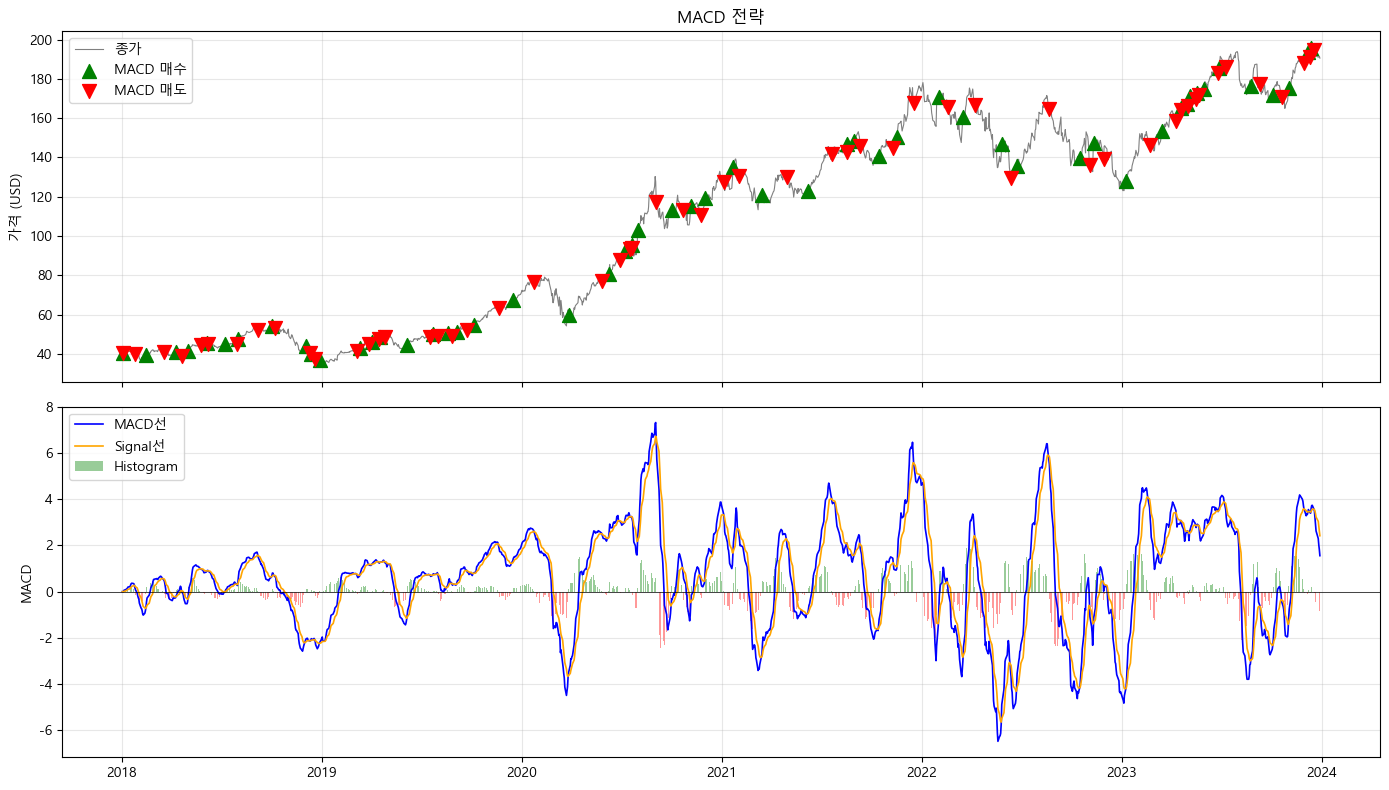

In [24]:
# ─── MACD 시각화 ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 상단: 가격 차트
ax1.plot(close, color='gray', linewidth=0.8, label='종가')
ax1.scatter(close.index[macd_entries], close[macd_entries],
            marker='^', color='green', s=100, zorder=5, label='MACD 매수')
ax1.scatter(close.index[macd_exits], close[macd_exits],
            marker='v', color='red', s=100, zorder=5, label='MACD 매도')
ax1.set_title('MACD 전략')
ax1.set_ylabel('가격 (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# 하단: MACD 차트
ax2.plot(macd_line,   color='blue',   linewidth=1.2, label='MACD선')
ax2.plot(signal_line, color='orange', linewidth=1.2, label='Signal선')
colors = ['green' if h >= 0 else 'red' for h in histogram]
ax2.bar(histogram.index, histogram, color=colors, alpha=0.4, label='Histogram')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_ylabel('MACD')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# ─── MACD 전략 백테스트 ───────────────────────────────────────────
pf_macd = vbt.Portfolio.from_signals(
    close, macd_entries, macd_exits,
    fees=0.001, slippage=0.001, freq='D'
)

print('=== MACD 전략 성과 ===')
print(f'총 수익률  : {pf_macd.total_return():.2%}')
print(f'연평균수익률: {pf_macd.annualized_return():.2%}')
print(f'샤프 비율  : {pf_macd.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_macd.max_drawdown():.2%}')
print(f'총 거래수  : {pf_macd.trades.count()}회')

=== MACD 전략 성과 ===
총 수익률  : 249.61%
연평균수익률: 35.36%
샤프 비율  : 1.42
최대 낙폭  : -27.90%
총 거래수  : 54회


---
## 4. 전략 종합 비교

세 전략의 성과를 한눈에 비교합니다.

In [26]:
# Buy & Hold 벤치마크 생성
bh_entries = pd.Series(False, index=close.index)
bh_exits   = pd.Series(False, index=close.index)
bh_entries.iloc[0] = True
bh_exits.iloc[-1]  = True
pf_bh = vbt.Portfolio.from_signals(close, bh_entries, bh_exits, fees=0.001, freq='D')

# 성과 비교 테이블
strategies = {
    'Buy & Hold': pf_bh,
    '골든크로스(MA20/60)': pf_gc,
    'RSI(14, 30/70)': pf_rsi,
    'MACD(12/26/9)': pf_macd,
}

rows = []
for name, pf in strategies.items():
    rows.append({
        '전략': name,
        '총 수익률': f'{pf.total_return():.2%}',
        '연평균수익률': f'{pf.annualized_return():.2%}',
        '샤프비율': f'{pf.sharpe_ratio():.2f}',
        '최대낙폭': f'{pf.max_drawdown():.2%}',
        '거래횟수': pf.trades.count(),
    })

comparison_df = pd.DataFrame(rows).set_index('전략')
print('=== 전략 비교 요약 ===')
print(comparison_df.to_string())

=== 전략 비교 요약 ===
                  총 수익률  연평균수익률  샤프비율     최대낙폭  거래횟수
전략                                                  
Buy & Hold      371.84%  45.54%  1.18  -38.52%     1
골든크로스(MA20/60)  194.14%  29.82%  1.10  -21.63%    15
RSI(14, 30/70)  122.68%  21.37%  0.87  -26.94%     7
MACD(12/26/9)   249.61%  35.36%  1.42  -27.90%    54


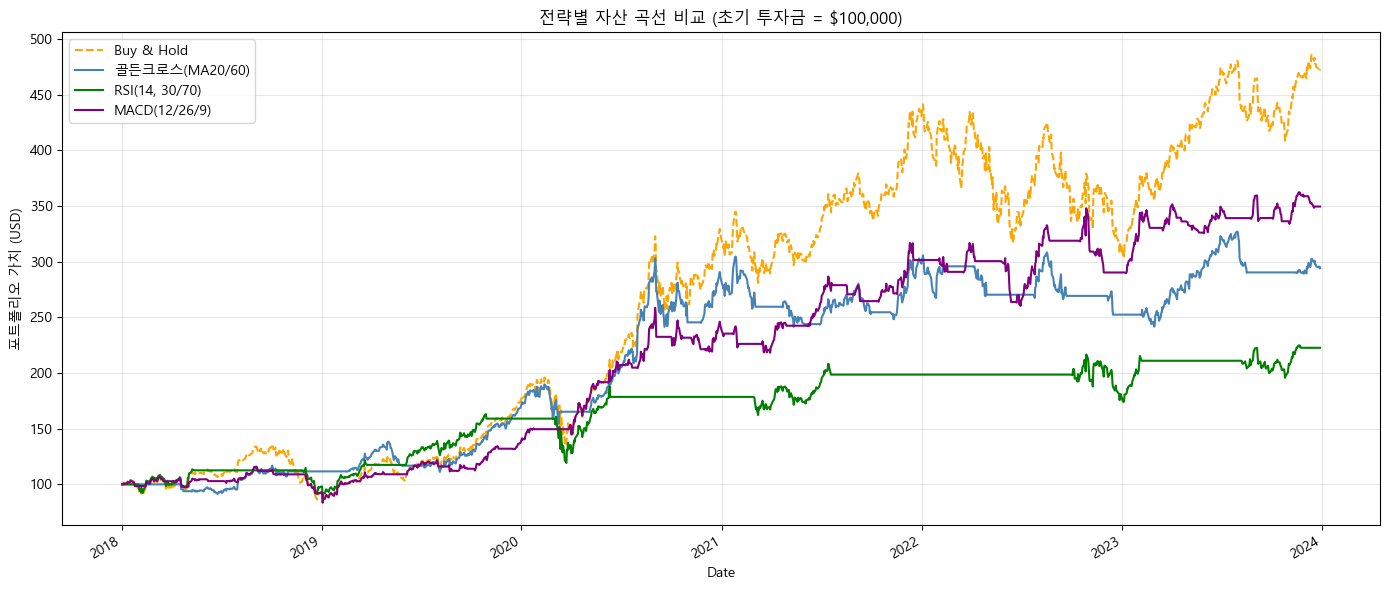

In [27]:
# 자산 곡선 비교 차트
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['orange', 'steelblue', 'green', 'purple']
styles = ['--', '-', '-', '-']

for (name, pf), color, style in zip(strategies.items(), colors, styles):
    pf.value().plot(ax=ax, label=name, color=color, linestyle=style, linewidth=1.5)

ax.set_title('전략별 자산 곡선 비교 (초기 투자금 = $100,000)')
ax.set_ylabel('포트폴리오 가치 (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. 실전 팁: 전략 조합 (MA + RSI 필터)

단일 지표보다 **여러 지표를 조합**하면 잘못된 신호(False Signal)를 줄일 수 있습니다.

예시: 골든크로스 + RSI 과매도 아님(RSI > 40) 조건을 동시에 만족할 때만 매수

In [28]:
# MA 골든크로스 AND RSI > 40 (과매도 아님) → 더 신뢰도 높은 매수 신호
combo_entries = gc_entries & (rsi > 40)
combo_exits   = gc_exits   | (rsi > rsi_overbought)  # 데드크로스 OR RSI 과매수

pf_combo = vbt.Portfolio.from_signals(
    close, combo_entries, combo_exits,
    fees=0.001, slippage=0.001, freq='D'
)

print('=== MA + RSI 복합 전략 ===')
print(f'총 수익률  : {pf_combo.total_return():.2%}')
print(f'샤프 비율  : {pf_combo.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_combo.max_drawdown():.2%}')
print(f'총 거래수  : {pf_combo.trades.count()}회')
print()
print(f'(참고) 골든크로스 단독   샤프: {pf_gc.sharpe_ratio():.2f}')
print(f'(참고) MA + RSI 복합     샤프: {pf_combo.sharpe_ratio():.2f}')

=== MA + RSI 복합 전략 ===
총 수익률  : 44.49%
샤프 비율  : 0.82
최대 낙폭  : -13.30%
총 거래수  : 12회

(참고) 골든크로스 단독   샤프: 1.10
(참고) MA + RSI 복합     샤프: 0.82


## 이번 단계 정리

| 전략 | 유형 | 적합한 시장 | 특징 |
|-----|------|------------|------|
| **골든크로스** | 추세 추종 | 강한 추세장 | 거래 횟수 적음, 큰 추세 캐치 |
| **RSI** | 역추세 | 횡보장 | 과매수/과매도 반전 노림 |
| **MACD** | 추세 + 모멘텀 | 추세 전환점 | EMA 기반, 반응 빠름 |
| **복합** | 혼합 | 범용 | False Signal 감소, 거래 수 감소 |

### 다음 단계
4단계에서는 `pf.stats()`로 세부 성과를 분석하고, **파라미터 최적화(Grid Search)** 및  
**과최적화(Overfitting)** 방지를 위한 in-sample / out-of-sample 분리 검증을 배웁니다.

In [ ]:
# ─── 골든크로스 vs 볼린저 밴드 성과 비교 ────────────────────────────
strategies_compare = {
    'Buy & Hold': pf_bh,
    '골든크로스(MA20/60)': pf_gc,
    '볼린저밴드(20일, 2σ)': pf_bb,
}

rows = []
for name, pf in strategies_compare.items():
    rows.append({
        '전략': name,
        '총 수익률': f'{pf.total_return():.2%}',
        '연평균수익률': f'{pf.annualized_return():.2%}',
        '샤프비율': f'{pf.sharpe_ratio():.2f}',
        '최대낙폭': f'{pf.max_drawdown():.2%}',
        '거래횟수': pf.trades.count(),
    })

compare_df = pd.DataFrame(rows).set_index('전략')
print('=== 골든크로스 vs 볼린저 밴드 비교 ===')
print(compare_df.to_string())

# ─── 자산 곡선 비교 ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

color_map = {'Buy & Hold': 'orange', '골든크로스(MA20/60)': 'steelblue', '볼린저밴드(20일, 2σ)': 'seagreen'}
style_map = {'Buy & Hold': '--', '골든크로스(MA20/60)': '-', '볼린저밴드(20일, 2σ)': '-'}

for name, pf in strategies_compare.items():
    pf.value().plot(ax=ax, label=name, color=color_map[name],
                    linestyle=style_map[name], linewidth=1.5)

ax.set_title('골든크로스 vs 볼린저 밴드 · 자산 곡선 비교')
ax.set_ylabel('포트폴리오 가치 (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 전략 비교 · 골든크로스 vs 볼린저 밴드

### 장단점 요약

| 항목 | 골든크로스 | 볼린저 밴드 |
|------|----------|-----------|
| **전략 유형** | 추세 추종 | 변동성 + 평균 회귀 |
| **적합 시장** | 강한 추세장 | 횡보·박스권 |
| **추세장 성과** | ✅ 큰 수익 가능 | ❌ 역추세 진입 위험 |
| **횡보장 성과** | ❌ 휩쏘 반복 손실 | ✅ 반복 매매로 수익 |
| **신호 후행성** | 높음 (MA 평균화 특성) | 낮음 (밴드가 즉시 반응) |
| **파라미터 민감도** | 낮음 | 중간 (기간·σ 배수) |
| **거짓 신호** | 횡보장에서 다수 | 강한 추세에서 다수 |

### 결론
- 두 전략은 **서로 약점을 보완**하는 관계
- 실전에서는 **조합 사용** 권장: 볼린저 하단 터치 + 골든크로스 동시 발생 시에만 매수

In [ ]:
# ─── 볼린저 밴드 백테스트 ──────────────────────────────────────────
pf_bb = vbt.Portfolio.from_signals(
    close, bb_entries, bb_exits,
    fees=0.001, slippage=0.001, freq='D'
)

print('=== 볼린저 밴드 전략 성과 ===')
print(f'총 수익률  : {pf_bb.total_return():.2%}')
print(f'연평균수익률: {pf_bb.annualized_return():.2%}')
print(f'샤프 비율  : {pf_bb.sharpe_ratio():.2f}')
print(f'최대 낙폭  : {pf_bb.max_drawdown():.2%}')
print(f'총 거래수  : {pf_bb.trades.count()}회')

In [ ]:
# ─── 시각화: 가격 + 볼린저 밴드 + 시그널 ────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close, color='gray', linewidth=0.8, label='종가', alpha=0.7)
ax.plot(bb_mid,   color='steelblue', linewidth=1.0, linestyle='--', label=f'중간밴드(MA{bb_window})')
ax.plot(bb_upper, color='tomato',    linewidth=1.0, label=f'상단밴드(+{bb_num_std}σ)')
ax.plot(bb_lower, color='seagreen',  linewidth=1.0, label=f'하단밴드(-{bb_num_std}σ)')
ax.fill_between(close.index, bb_upper, bb_lower, alpha=0.05, color='steelblue')

ax.scatter(close.index[bb_entries], close[bb_entries],
           marker='^', color='green', s=100, zorder=5, label='매수(하단 돌파)')
ax.scatter(close.index[bb_exits], close[bb_exits],
           marker='v', color='red',   s=100, zorder=5, label='매도(상단 이탈)')

ax.set_title('볼린저 밴드 전략')
ax.set_ylabel('가격 (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ─── 볼린저 밴드 계산 ─────────────────────────────────────────────
bb_window  = 20    # 이동평균 기간
bb_num_std = 2.0   # 표준편차 배수

bb_mid   = close.rolling(bb_window).mean()
bb_std   = close.rolling(bb_window).std()
bb_upper = bb_mid + bb_num_std * bb_std
bb_lower = bb_mid - bb_num_std * bb_std

# ─── 시그널 생성 ─────────────────────────────────────────────────
# 하단 밴드를 아래에서 위로 돌파 → 매수
bb_entries = (close > bb_lower) & (close.shift(1) <= bb_lower.shift(1))
# 상단 밴드를 위에서 아래로 돌파 → 매도
bb_exits   = (close < bb_upper) & (close.shift(1) >= bb_upper.shift(1))

print(f'볼린저 밴드 매수 시그널: {bb_entries.sum()}회')
print(f'볼린저 밴드 매도 시그널: {bb_exits.sum()}회')

---
## 전략 4 · 볼린저 밴드 (Bollinger Bands)

### 개념
볼린저 밴드는 이동평균에 **표준편차(σ)** 를 더하고 빼서 상·하단 밴드를 만듭니다.

```
상단 밴드 = MA(20) + 2σ   ← 가격이 여기서 내려오면 → 매도
중간 밴드 = MA(20)
하단 밴드 = MA(20) - 2σ   ← 가격이 여기서 올라오면 → 매수
```

### 매매 신호 (평균 회귀 방식)
- **하단 밴드를 아래→위 돌파**: 과매도 해소 → **매수**
- **상단 밴드를 위→아래 돌파**: 과매수 해소 → **매도**

### 특징
- **변동성 반영**: 밴드 폭이 시장 변동성에 따라 자동 확장/수축
- **평균 회귀형**: 횡보장에서 반복 매매로 수익 추구
- **추세장 위험**: 강한 추세에서 역방향 진입 가능성